# Notebook 01b — Hand Dataset Preparation (No Augmentation)
**FracAtlas YOLOv12m Fracture Detection Pipeline**

This notebook prepares the **original (non-augmented) hand X-ray subset** into a YOLO-ready dataset format with train/val/test splits.

> **Run this INSTEAD OF Notebook 01b_hand_augmentation if you do NOT want augmentation.**

## 0. Install & Import Dependencies

In [1]:
# Install required packages (run once if not installed)
# !pip install pandas scikit-learn tqdm Pillow PyYAML

import os
import shutil
import random
import warnings
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import yaml
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
random.seed(42)
print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Configure Paths

In [2]:
# ─── EDIT THESE PATHS TO MATCH YOUR SETUP ───────────────────────────────────
BASE_DIR       = Path.cwd().parent  # Go up one level from notebooks/
IMAGES_DIR     = BASE_DIR / "images"
ANNOT_DIR      = BASE_DIR / "Annotations" / "YOLO"
DATASET_CSV    = BASE_DIR / "dataset.csv"

# Output directories for non-augmented dataset
OUTPUT_DIR     = BASE_DIR / "yolo_dataset_hand"
YAML_PATH      = BASE_DIR / "fracatlas_hand.yaml"
# ─────────────────────────────────────────────────────────────────────────────

# Create output directory structure
for split in ["train", "val", "test"]:
    (OUTPUT_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

YAML_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f"Base directory   : {BASE_DIR.resolve()}")
print(f"Images directory : {IMAGES_DIR.resolve()}")
print(f"Annotations dir  : {ANNOT_DIR.resolve()}")
print(f"Output dataset   : {OUTPUT_DIR.resolve()}")

Base directory   : D:\Project Medical Object Detection\FracAtlas
Images directory : D:\Project Medical Object Detection\FracAtlas\images
Annotations dir  : D:\Project Medical Object Detection\FracAtlas\Annotations\YOLO
Output dataset   : D:\Project Medical Object Detection\FracAtlas\yolo_dataset_hand


## 2. Load Hand Dataset Information

In [3]:
# Load dataset metadata to identify hand images
df = pd.read_csv(DATASET_CSV)

# Filter for hand images only
hand_df = df[df['hand'] == 1].copy()
print(f"Total hand images in dataset: {len(hand_df)}")

# Check fracture distribution
n_frac = (hand_df['fractured'] == 1).sum()
n_non_frac = (hand_df['fractured'] == 0).sum()
print(f"  Fractured:     {n_frac} ({100*n_frac/len(hand_df):.1f}%)")
print(f"  Non-fractured: {n_non_frac} ({100*n_non_frac/len(hand_df):.1f}%)")
print(f"  Ratio (Non-frac / Frac): {n_non_frac / n_frac:.2f}:1")

# Create image_id to label mapping
img_to_label = {}
for _, row in hand_df.iterrows():
    img_id = row['image_id']
    is_fractured = row['fractured'] == 1
    img_to_label[img_id] = 'Fractured' if is_fractured else 'Non-fractured'

Total hand images in dataset: 1538
  Fractured:     438 (28.5%)
  Non-fractured: 1100 (71.5%)
  Ratio (Non-frac / Frac): 2.51:1


## 3. Collect Hand Images

In [4]:
# Get all hand image paths
hand_image_ids = hand_df['image_id'].tolist()

# Map image_id to actual file path
frac_dir = IMAGES_DIR / "Fractured"
non_frac_dir = IMAGES_DIR / "Non_fractured"

# Build a lookup table of all available images
print(f"Scanning image directories...")
print(f"  Fractured dir: {frac_dir}")
print(f"  Non-fractured dir: {non_frac_dir}")

available_images = {}
for ext in ['.jpg', '.jpeg', '.png']:
    for img_path in frac_dir.glob(f"*{ext}"):
        available_images[img_path.name] = (img_path, True)  # True = fractured
    for img_path in non_frac_dir.glob(f"*{ext}"):
        available_images[img_path.name] = (img_path, False)  # False = non-fractured

print(f"Found {len(available_images)} total images in directories")

def find_image_path(img_id: str):
    """Find the actual image path for an image_id."""
    if not any(img_id.endswith(ext) for ext in ['.jpg', '.jpeg', '.png']):
        img_id = img_id + '.jpg'  # Default extension
    
    if img_id in available_images:
        return available_images[img_id]
    return None, None

# Collect all hand images with their labels
hand_images = []
for img_id in hand_image_ids:
    img_path, is_fractured = find_image_path(img_id)
    if img_path:
        label_path = ANNOT_DIR / f"{img_path.stem}.txt"
        hand_images.append({
            'image_id': img_id,
            'img_path': img_path,
            'label_path': label_path,
            'is_fractured': is_fractured
        })
    else:
        print(f"  Warning: Image not found: {img_id}")

print(f"\nFound {len(hand_images)} hand images to process")

Scanning image directories...
  Fractured dir: d:\Project Medical Object Detection\FracAtlas\images\Fractured
  Non-fractured dir: d:\Project Medical Object Detection\FracAtlas\images\Non_fractured
Found 4083 total images in directories

Found 1538 hand images to process


## 4. Create Train/Val/Test Splits

In [5]:
from sklearn.model_selection import train_test_split

# 1. Prepare image list and fracture labels for stratified splitting
all_img_paths = [item['img_path'] for item in hand_images]
fracture_labels = [item['is_fractured'] for item in hand_images]

print(f"Total images to split: {len(all_img_paths)}")

# 2. Perform Split (70% Train, 15% Val, 15% Test) with stratification
train_items, temp_items, train_labels, temp_labels = train_test_split(
    hand_images, fracture_labels, 
    test_size=0.30, stratify=fracture_labels, random_state=42
)

val_items, test_items, _, _ = train_test_split(
    temp_items, temp_labels,
    test_size=0.50, stratify=temp_labels, random_state=42
)

print(f"\nDataset splits:")
print(f"  Train: {len(train_items)} images")
print(f"  Val:   {len(val_items)} images")
print(f"  Test:  {len(test_items)} images")

# 3. Copy images and labels to output directories
def copy_to_split(items: list, split_name: str):
    for item in tqdm(items, desc=f"Copying {split_name}"):
        img_path = item['img_path']
        label_path = item['label_path']
        
        # Copy image
        dst_img = OUTPUT_DIR / split_name / "images" / img_path.name
        shutil.copy2(str(img_path), str(dst_img))
        
        # Copy label (if exists)
        dst_label = OUTPUT_DIR / split_name / "labels" / f"{img_path.stem}.txt"
        if label_path.exists():
            shutil.copy2(str(label_path), str(dst_label))
        else:
            # Create empty label file for non-fractured images
            dst_label.touch()

copy_to_split(train_items, "train")
copy_to_split(val_items, "val")
copy_to_split(test_items, "test")

print("\n✓ Splits created and organized successfully!")

Total images to split: 1538

Dataset splits:
  Train: 1076 images
  Val:   231 images
  Test:  231 images


Copying test: 100%|██████████| 231/231 [00:01<00:00, 171.33it/s]


✓ Splits created and organized successfully!


## 5. Verify Final Dataset Statistics

In [6]:
# Count images and labels per split
def count_images_and_labels(split: str):
    img_dir = OUTPUT_DIR / split / "images"
    label_dir = OUTPUT_DIR / split / "labels"
    
    images = list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.jpeg"))
    n_images = len(images)
    
    n_frac = 0
    n_non_frac = 0
    
    for img in images:
        label_path = label_dir / f"{img.stem}.txt"
        if label_path.exists() and label_path.stat().st_size > 0:
            n_frac += 1
        else:
            n_non_frac += 1
    
    return n_images, n_frac, n_non_frac

print("\n📊 Hand Dataset Summary (No Augmentation):")
print("=" * 60)
print(f"{'Split':<10} | {'Images':<8} | {'Fractured':<12} | {'Non-fractured':<15}")
print("=" * 60)

total_images = 0
total_frac = 0
total_non_frac = 0

for split in ["train", "val", "test"]:
    n_img, n_frac, n_non_frac = count_images_and_labels(split)
    total_images += n_img
    total_frac += n_frac
    total_non_frac += n_non_frac
    print(f"{split.capitalize():<10} | {n_img:<8} | {n_frac:<12} | {n_non_frac:<15}")

print("=" * 60)
print(f"{'TOTAL':<10} | {total_images:<8} | {total_frac:<12} | {total_non_frac:<15}")
print("\n✓ Dataset preparation complete!")


📊 Hand Dataset Summary (No Augmentation):
Split      | Images   | Fractured    | Non-fractured  
Train      | 1076     | 306          | 770            
Val        | 231      | 66           | 165            
Test       | 231      | 66           | 165            
TOTAL      | 1538     | 438          | 1100           

✓ Dataset preparation complete!


## 6. Generate YOLO Configuration YAML

In [7]:
yaml_config = {
    'path': str(OUTPUT_DIR.resolve()),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': 1,
    'names': ['fracture']
}

# Save YAML file
with open(YAML_PATH, 'w') as f:
    yaml.dump(yaml_config, f, default_flow_style=None, sort_keys=False)

print(f"✓ YAML config saved to: {YAML_PATH}")
print("\nYAML contents:")
print("-" * 40)
with open(YAML_PATH) as f:
    print(f.read())

✓ YAML config saved to: d:\Project Medical Object Detection\FracAtlas\fracatlas_hand.yaml

YAML contents:
----------------------------------------
path: D:\Project Medical Object Detection\FracAtlas\yolo_dataset_hand
train: train/images
val: val/images
test: test/images
nc: 1
names: [fracture]



## 7. Visualize Sample Images

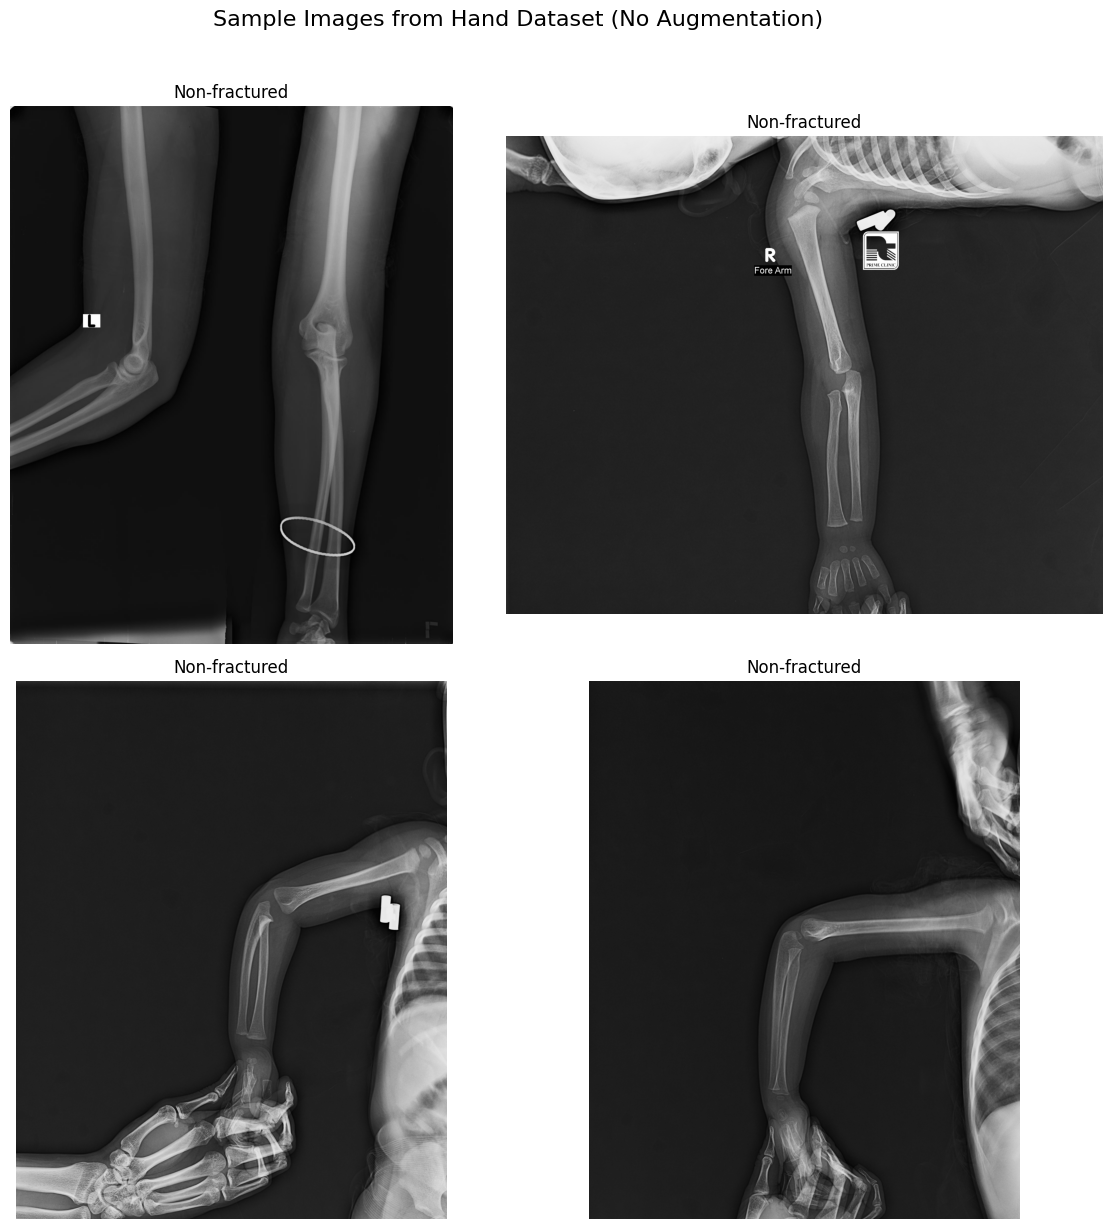


✓ Dataset ready for training! Use config: d:\Project Medical Object Detection\FracAtlas\fracatlas_hand.yaml


In [8]:
import cv2
import matplotlib.patches as patches

def visualize_sample(img_path: Path, label_path: Path, ax):
    """Visualize an image with its bounding boxes."""
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]
    
    ax.imshow(img)
    
    # Draw bounding boxes
    if label_path.exists() and label_path.stat().st_size > 0:
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id, cx, cy, w, h = map(float, parts)
                    x1 = (cx - w/2) * img_w
                    y1 = (cy - h/2) * img_h
                    bw = w * img_w
                    bh = h * img_h
                    rect = patches.Rectangle((x1, y1), bw, bh, linewidth=2, 
                                            edgecolor='red', facecolor='none')
                    ax.add_patch(rect)
    
    ax.axis('off')
    is_fractured = label_path.exists() and label_path.stat().st_size > 0
    ax.set_title(f"{'Fractured' if is_fractured else 'Non-fractured'}", fontsize=12)

# Sample visualization
train_img_dir = OUTPUT_DIR / "train" / "images"
train_label_dir = OUTPUT_DIR / "train" / "labels"

sample_imgs = list(train_img_dir.glob("*.jpg"))[:4]
if len(sample_imgs) == 0:
    sample_imgs = list(train_img_dir.glob("*.png"))[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, img_path in enumerate(sample_imgs):
    label_path = train_label_dir / f"{img_path.stem}.txt"
    visualize_sample(img_path, label_path, axes[i])

plt.suptitle("Sample Images from Hand Dataset (No Augmentation)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n✓ Dataset ready for training! Use config: {YAML_PATH}")